In [1]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import h5py
import importlib
from skyfield.api import load, EarthSatellite, Topos, wgs84


BDC is using numpy


In [2]:
day = '10_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_24'

with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]

ref_coords = coords[0]
v_nchunks = int((visibility_window)/(v_acclen* T_SPECTRA))

context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(context)
print(global_start_time)


[1000, 1.6384e-05, 30000, 2034, [79.41718333333333, -90.76735, 189]]
1699593012


In [4]:
pl = []


#with h5py.File(f'vis_all_{global_start_time}_10hrs.h5', 'r') as f:

with h5py.File(f'{working_directory}/{bits}bit/{day}/visraw_bline{baseline_idx}_{global_start_time}.h5', 'r') as f:
    for p in f:
        pulse_info = []
        pulse_info.append(p) #index 0
        pulse_info.append([int(f[p].attrs['start_time']), int(f[p].attrs['end_time']), int(f[p].attrs['global_start_time'])]) # index 1
        pulse_info.append(json.loads(f[p].attrs['sats'])) #index 2
        #pulse_info.append(f[p].attrs['tle_path']) #index 3
        pulse_info.append(outils.get_tle_file(int(f[p].attrs['global_start_time']) + int(f[p].attrs['start_time']), "/project/s/sievers/mohanagr/OCOMM_TLES"))
        pulse_info.append(f[f'/{p}'][:])  # index 4
        pl.append(pulse_info)

for pulse in pl:
    print(pulse)
print(len(pl))

#note on ordering of the pulse_data list:

# example entry:   [[relative_start_time, relative_end_time, global_start_time], {satID:[chan1, chan2]}, tle_path, [observed data array]]

['0_1000', [1000, 1220, 1699593012], {'33591': [1850]}, '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt', array([[-0.02366487-0.0127756j , -0.02083885+0.00324622j,
         0.01895399-0.00659714j, ..., -0.0081681 +0.01361346j,
        -0.09944   -0.12181748j, -0.00753918+0.02220012j],
       [ 0.0034557 -0.01183325j,  0.0070162 -0.02314254j,
         0.02565563+0.0103672j , ..., -0.01183286-0.01455589j,
        -0.08082044-0.18759072j, -0.00869166-0.0013613j ],
       [-0.02125771-0.0036649j ,  0.01026246-0.00020942j,
        -0.0021991 -0.00408399j, ..., -0.00513055-0.01162377j,
        -0.02638835-0.14960083j, -0.02136234+0.00335099j],
       ...,
       [-0.00062832+0.00565472j,  0.00712073+0.01382238j,
        -0.00764452+0.00680655j, ..., -0.01832568+0.01916322j,
        -0.01602193-0.01120484j,  0.01214736-0.00963415j],
       [ 0.02544594-0.00387461j, -0.00942473+0.00439809j,
        -0.01078607-0.02083858j, ..., -0.0048171 -0.00125662j,
        -0.0075398 -0.00

In [44]:
info_dict = {}
good_idx_set = set({})

In [45]:
pulse_idx = 0

label = pl[pulse_idx][0]
times = pl[pulse_idx][1]
satID = int(list(pl[pulse_idx][2].keys())[0])  #for now only worry about one satellite
channels_present = list(pl[pulse_idx][2].values())[0]
tle_path = pl[pulse_idx][3]

#here I might want to interpolate in v2?
phased_visibility = np.angle(pl[pulse_idx][4])


print(label)
print(times)
print(satID)
print(channels_present)
print(tle_path)

0_1000
[1000, 1220, 1699593012]
33591
[1850]
/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt


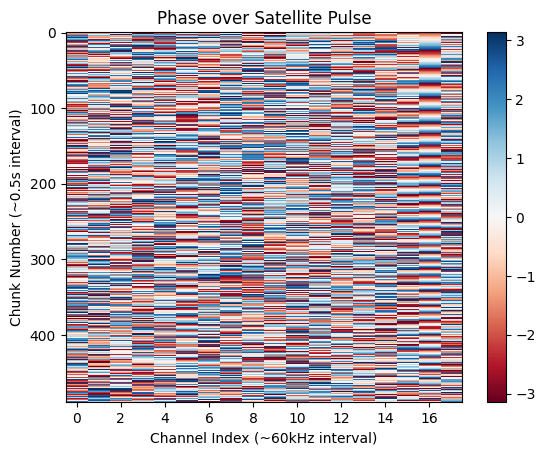

In [46]:
plt.xlabel("Channel Index (~60kHz interval)")
plt.ylabel("Chunk Number (~0.5s interval)")
plt.title("Phase over Satellite Pulse")
plt.imshow(phased_visibility, aspect='auto',cmap='RdBu',interpolation="none")
plt.colorbar()

In [47]:
chan_small = 16

channel_list = np.arange(1834, 1852, dtype=int)

chan_big = int(channel_list[chan_small])
print("big chan idx:", chan_big)
chans_present = [int(np.where(chan==channel_list)[0][0]) for chan in channels_present]
print(chans_present)
noise_chans = np.setdiff1d(np.arange(18), chans_present)
print(noise_chans)


big chan idx: 1850
[16]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17]


sanity check: starting phase value: 0.0
original length 489


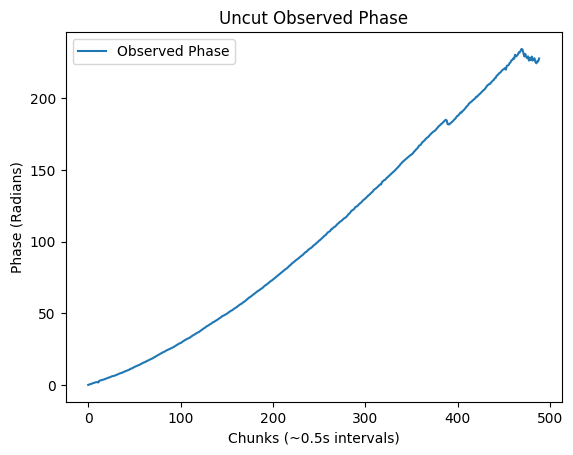

In [48]:
phase_data = np.unwrap(phased_visibility[ : , chan_small] - phased_visibility[0, chan_small])

plt.plot(phase_data, label="Observed Phase")
plt.xlabel("Chunks (~0.5s intervals)")
plt.ylabel("Phase (Radians)")
plt.title("Uncut Observed Phase")
plt.legend()

print("sanity check: starting phase value:", phase_data[0])
print("original length", len(phase_data))

duration in chunks: 350
duration in seconds: 172.032
0.0


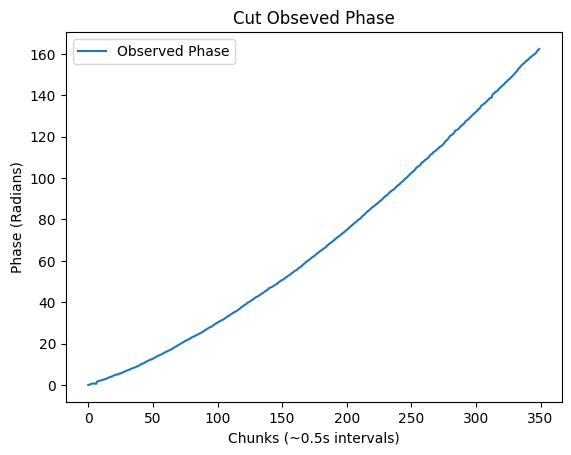

In [49]:
shift_c = 5
duration_c = 350

# should this be ceil or int?
duration_s = duration_c * (context[2]*context[1])
shift_s = shift_c * (context[2]*context[1])
print('duration in chunks:', duration_c)
print('duration in seconds:', duration_s)

phase_data = np.unwrap(phased_visibility[shift_c :  duration_c + shift_c, chan_small] - phased_visibility[shift_c, chan_small])
print(phase_data[0])


plt.plot(phase_data, label="Observed Phase")
plt.xlabel("Chunks (~0.5s intervals)")
plt.ylabel("Phase (Radians)")
plt.title("Cut Obseved Phase")
plt.legend()

In [50]:
new_data = pl[pulse_idx][4][shift_c : shift_c + duration_c, :]


column_data = []
for idx in noise_chans:
    column_data.append(new_data[:, idx])
std_real = np.std(np.real(column_data))
std_imag = np.std(np.imag(column_data))
#column_noise = np.sqrt((std_real**2 + std_imag**2))

row_noise = 0

new_start_time = times[0] + shift_s

new_end_time =   times[0] + shift_s + duration_s

info_dict[label] = [label, [new_start_time, new_end_time, times[2]], [satID, chan_big], tle_path, phase_data, (std_real, std_imag), row_noise]

In [51]:
print(info_dict)

{'0_1000': ['0_1000', [1002.4576, 1174.4895999999999, 1699593012], [33591, 1850], '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt', array([0.00000000e+00, 1.39633149e-01, 4.23871046e-01, 5.78220591e-01,
       7.58353705e-01, 6.90459045e-01, 5.20989186e-01, 1.70004431e+00,
       1.91948592e+00, 2.02567189e+00, 2.25773321e+00, 2.40050961e+00,
       2.59272021e+00, 2.82823269e+00, 2.99887607e+00, 3.33683445e+00,
       3.61438982e+00, 3.90104092e+00, 3.98626504e+00, 4.34782230e+00,
       4.63963689e+00, 4.86677017e+00, 4.96427757e+00, 5.11536693e+00,
       5.44301613e+00, 5.58391959e+00, 5.88373345e+00, 6.14487162e+00,
       6.40704432e+00, 6.77784999e+00, 6.96967382e+00, 7.17270912e+00,
       7.45018832e+00, 7.66929497e+00, 8.02465585e+00, 8.20753171e+00,
       8.48318774e+00, 8.80805741e+00, 9.01617204e+00, 9.28036088e+00,
       9.67558016e+00, 1.00830522e+01, 1.02569803e+01, 1.05712578e+01,
       1.09488921e+01, 1.12936479e+01, 1.16560840e+01, 1.18482993e+01,

In [54]:
good_idx_set.add(label)
print(good_idx_set)
print(len(good_idx_set))

{'0_1000'}
1


In [ ]:
with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_selected_bline_{baseline_idx}_{global_start_time}.h5', 'w') as f:
    for idx in range(len(good_pulse_data)):
        #name the data after the label
        pulse_array = f.create_dataset(f'{good_pulse_data[idx][0]}', data=good_pulse_data[idx][4])

        pulse_array.attrs['start_time']        = good_pulse_data[idx][1][0]
        pulse_array.attrs['end_time']          = good_pulse_data[idx][1][1]
        pulse_array.attrs['global_start_time'] = good_pulse_data[idx][1][2]
        pulse_array.attrs['sat']               = good_pulse_data[idx][2][0]
        pulse_array.attrs['chan']              = good_pulse_data[idx][2][1]
        pulse_array.attrs['tle_path']          = good_pulse_data[idx][3]
        #add std stuff!!!!

    f.attrs["vis_window"] = visibility_window
    f.attrs["v_acclen"] = v_acclen
    f.attrs["T_SPECTRA"] = V_T_ACCLEN
    f.attrs["v_nchunks"] = v_nchunks
    f.attrs["ref_coords"] = ref_coords #necessary?
    f.attrs["baseline_idx"] = baseline_idx